In [15]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, balanced_accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier,HistGradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/playground-series-s6e7/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e7/train.csv
/kaggle/input/competitions/playground-series-s6e7/test.csv
/kaggle/input/datasets/ziya07/college-student-health-behavior-dataset/enhanced_student_health_dataset_50k.xls
/kaggle/input/datasets/ziya07/college-student-health-behavior-dataset/student_health_dataset_50k.csv


In [16]:
train=pd.read_csv('/kaggle/input/competitions/playground-series-s6e7/train.csv')
test=pd.read_csv('/kaggle/input/competitions/playground-series-s6e7/test.csv')
external=pd.read_csv('/kaggle/input/datasets/ziya07/college-student-health-behavior-dataset/student_health_dataset_50k.csv')

In [17]:
print("train shape:", train.shape)
print("test shape:", test.shape)
print("external shape:", external.shape)

print("\n--- train columns ---")
print(train.columns.tolist())

print("\n--- test columns ---")
print(test.columns.tolist())

print("\n--- external columns ---")
print(external.columns.tolist())

train shape: (690088, 15)
test shape: (295753, 14)
external shape: (50000, 16)

--- train columns ---
['id', 'health_condition', 'sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake', 'diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']

--- test columns ---
['id', 'sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake', 'diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']

--- external columns ---
['student_id', 'timestamp', 'sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake', 'diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender', 'health_condition']


In [18]:
train.health_condition.value_counts()

health_condition
at-risk      592561
unhealthy     57724
fit           39803
Name: count, dtype: int64

In [19]:
external.health_condition.value_counts()

health_condition
at-risk      43718
unhealthy     3816
fit           2466
Name: count, dtype: int64

In [20]:
train.dtypes

id                           int64
health_condition            object
sleep_duration             float64
heart_rate                 float64
bmi                        float64
calorie_expenditure        float64
step_count                 float64
exercise_duration          float64
water_intake               float64
diet_type                   object
stress_level                object
sleep_quality               object
physical_activity_level     object
smoking_alcohol             object
gender                      object
dtype: object

In [21]:
external.dtypes

student_id                   int64
timestamp                   object
sleep_duration             float64
heart_rate                 float64
bmi                        float64
calorie_expenditure        float64
step_count                   int64
exercise_duration          float64
water_intake               float64
diet_type                   object
stress_level                object
sleep_quality               object
physical_activity_level     object
smoking_alcohol             object
gender                      object
health_condition            object
dtype: object

In [22]:
test.dtypes

id                           int64
sleep_duration             float64
heart_rate                 float64
bmi                        float64
calorie_expenditure        float64
step_count                 float64
exercise_duration          float64
water_intake               float64
diet_type                   object
stress_level                object
sleep_quality               object
physical_activity_level     object
smoking_alcohol             object
gender                      object
dtype: object

In [23]:
train.isna().sum()

id                             0
health_condition               0
sleep_duration             75999
heart_rate                  7833
bmi                        13898
calorie_expenditure        52853
step_count                 13916
exercise_duration           6901
water_intake               43477
diet_type                   6901
stress_level               82811
sleep_quality              58331
physical_activity_level    36621
smoking_alcohol            28582
gender                     21373
dtype: int64

In [24]:
test.isna().sum()

id                             0
sleep_duration             32571
heart_rate                  3357
bmi                         5956
calorie_expenditure        22652
step_count                  5964
exercise_duration           2958
water_intake               18633
diet_type                   2958
stress_level               35490
sleep_quality              24999
physical_activity_level    15695
smoking_alcohol            12249
gender                      9160
dtype: int64

In [25]:
external.isna().sum()

student_id                 0
timestamp                  0
sleep_duration             0
heart_rate                 0
bmi                        0
calorie_expenditure        0
step_count                 0
exercise_duration          0
water_intake               0
diet_type                  0
stress_level               0
sleep_quality              0
physical_activity_level    0
smoking_alcohol            0
gender                     0
health_condition           0
dtype: int64

In [28]:
train.duplicated().sum()

np.int64(0)

In [29]:
print("Train duplicates:", train.duplicated().sum())
print("Test duplicates :", test.duplicated().sum())
print("External duplicates :", test.duplicated().sum())

Train duplicates: 0
Test duplicates : 0
External duplicates : 0


In [30]:
train.describe()

,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake
count,690088.00000,614089.000000,682255.000000,676190.000000,637235.000000,676172.000000,683187.000000,646611.000000
mean,345043.50000,6.992597,75.096504,22.984925,2226.084931,8615.953050,38.751456,2.188542
std,199211.39062,1.215407,8.175106,2.481787,347.532098,3929.399831,14.742189,0.518489
min,0.00000,3.000000,50.000000,16.000000,1200.000000,1002.000000,0.000000,0.500000
25%,172521.75000,6.160000,69.400000,21.320000,2053.000000,5389.000000,29.200000,1.840000
50%,345043.50000,6.990000,75.100000,22.990000,2241.000000,8856.000000,39.400000,2.170000
75%,517565.25000,7.810000,80.700000,24.660000,2456.000000,12114.000000,49.400000,2.500000
max,690087.00000,10.000000,107.700000,34.820000,3580.000000,14999.000000,99.800000,4.720000


In [31]:
test.describe()

,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake
count,295753.000000,263182.000000,292396.000000,289797.000000,273101.000000,289789.000000,292795.000000,277120.000000
mean,837964.000000,6.993517,75.079560,22.984661,2225.514941,8626.630524,38.796712,2.191508
std,85376.681419,1.216369,8.115118,2.478708,347.816761,3924.646677,14.711180,0.518771
min,690088.000000,3.000000,50.000000,16.000000,1201.000000,1002.000000,0.000000,0.500000
25%,764026.000000,6.160000,69.400000,21.320000,2052.000000,5394.000000,29.200000,1.850000
50%,837964.000000,6.990000,75.100000,22.990000,2240.000000,8857.000000,39.400000,2.180000
75%,911902.000000,7.810000,80.600000,24.650000,2455.000000,12120.000000,49.400000,2.500000
max,985840.000000,10.000000,103.700000,34.820000,3574.000000,14999.000000,98.400000,4.720000


In [32]:
external.describe()

,student_id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1501.943360,6.995989,75.002762,23.023812,2200.901460,7988.280340,40.098728,2.197891
std,289.067217,1.465308,9.930061,2.977059,398.811635,4044.517447,19.598865,0.696485
min,1000.000000,3.000000,50.000000,16.000000,1200.000000,1000.000000,0.000000,0.500000
25%,1252.000000,5.990000,68.300000,21.000000,1930.000000,4444.000000,26.400000,1.720000
50%,1505.000000,7.010000,75.000000,23.000000,2200.000000,8010.000000,39.900000,2.190000
75%,1753.000000,8.020000,81.700000,25.010000,2471.000000,11485.000000,53.400000,2.670000
max,1999.000000,10.000000,120.000000,35.000000,3901.000000,14999.000000,120.000000,4.940000


In [33]:
TARGET = 'health_condition'
ID_COL = 'id'

# categorical features used in modeling (excluding target)
cat_cols = [c for c in train.select_dtypes(include=['object', 'category']).columns if c != TARGET]
print("Categorical columns:", cat_cols)

def pct_series(s):
    return s.value_counts(normalize=True, dropna=False).rename('pct') * 100

for col in cat_cols:
    tr = pct_series(train[col]).rename('train_pct')
    te = pct_series(test[col]).rename('test_pct')
    ex = pct_series(external[col]).rename('external_pct') if col in external.columns else pd.Series(dtype=float, name='external_pct')

    comp = pd.concat([tr, te, ex], axis=1).fillna(0)
    comp['abs_diff_train_test'] = (comp['train_pct'] - comp['test_pct']).abs()
    comp['abs_diff_train_external'] = (comp['train_pct'] - comp['external_pct']).abs()
    comp = comp.sort_values('train_pct', ascending=False)

    print(f"\n\n===== {col} =====")
    display(comp.round(2))

    # summary drift score per column
    ttv_train_test = 0.5 * comp['abs_diff_train_test'].sum() / 100.0
    ttv_train_ext  = 0.5 * comp['abs_diff_train_external'].sum() / 100.0
    print(f"TVD(train,test)     = {ttv_train_test:.4f}")
    print(f"TVD(train,external) = {ttv_train_ext:.4f}")

Categorical columns: ['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']


===== diet_type =====


,train_pct,test_pct,external_pct,abs_diff_train_test,abs_diff_train_external
diet_type,,,,,
veg,33.54,33.50,33.08,0.04,0.46
balanced,32.88,32.96,33.45,0.08,0.57
non-veg,32.59,32.54,33.47,0.04,0.89
NaN,1.00,1.00,0.00,0.00,1.00


TVD(train,test)     = 0.0008
TVD(train,external) = 0.0146


===== stress_level =====


,train_pct,test_pct,external_pct,abs_diff_train_test,abs_diff_train_external
stress_level,,,,,
medium,37.94,38.06,40.39,0.12,2.45
high,25.76,25.64,29.97,0.12,4.21
low,24.30,24.30,29.64,0.00,5.34
NaN,12.00,12.00,0.00,0.00,12.00


TVD(train,test)     = 0.0012
TVD(train,external) = 0.1200


===== sleep_quality =====


...

TVD(train,test)     = 0.0086
TVD(train,external) = 0.0531


===== smoking_alcohol =====


,train_pct,test_pct,external_pct,abs_diff_train_test,abs_diff_train_external
smoking_alcohol,,,,,
yes,32.42,32.22,33.53,0.20,1.11
no,31.85,31.98,33.66,0.13,1.81
occasional,31.59,31.66,32.80,0.08,1.22
NaN,4.14,4.14,0.00,0.00,4.14


TVD(train,test)     = 0.0020
TVD(train,external) = 0.0414


===== gender =====


,train_pct,test_pct,external_pct,abs_diff_train_test,abs_diff_train_external
gender,,,,,
male,34.45,34.64,33.70,0.18,0.75
female,32.46,29.15,33.07,3.31,0.61
other,29.99,33.11,33.23,3.13,3.24
NaN,3.10,3.10,0.00,0.00,3.10


TVD(train,test)     = 0.0331
TVD(train,external) = 0.0385


In [34]:
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
if ID_COL in num_cols:
    num_cols.remove(ID_COL)

In [35]:
print("=== Numeric feature medians by target ===")
display(train.groupby(TARGET)[num_cols].median().T)

=== Numeric feature medians by target ===


health_condition,at-risk,fit,unhealthy
sleep_duration,7.03,7.84,5.53
heart_rate,75.10,74.50,75.10
bmi,22.96,22.25,23.70
calorie_expenditure,2235.00,2345.00,2255.00
step_count,8483.00,12342.50,8941.50
exercise_duration,38.60,50.50,39.70
water_intake,2.18,2.14,2.18


In [36]:
print("=== Numeric feature medians by target ===")
display(external.groupby(TARGET)[num_cols].median().T)

=== Numeric feature medians by target ===


health_condition,at-risk,fit,unhealthy
sleep_duration,7.06,8.010,5.29
heart_rate,75.00,74.850,75.20
bmi,22.99,22.975,23.07
calorie_expenditure,2199.00,2206.000,2208.00
step_count,8005.00,7891.000,8104.50
exercise_duration,39.80,39.650,40.40
water_intake,2.20,2.180,2.19


In [37]:
signal_rows = []
for c in num_cols:
    means = train.groupby(TARGET)[c].mean()
    std = train[c].std()
    score = (means.max() - means.min()) / (std + 1e-9)
    signal_rows.append((c, score))
signal_df = pd.DataFrame(signal_rows, columns=['feature', 'coarse_signal_score']).sort_values('coarse_signal_score', ascending=False)
print("\n=== Coarse numeric signal ranking ===")
display(signal_df)


=== Coarse numeric signal ranking ===


,feature,coarse_signal_score
0,sleep_duration,2.129487
2,bmi,0.924381
4,step_count,0.825724
5,exercise_duration,0.819242
3,calorie_expenditure,0.428877
1,heart_rate,0.055432
6,water_intake,0.019199


In [38]:
signal_rows = []
for c in num_cols:
    means = external.groupby(TARGET)[c].mean()
    std = external[c].std()
    score = (means.max() - means.min()) / (std + 1e-9)
    signal_rows.append((c, score))
signal_df = pd.DataFrame(signal_rows, columns=['feature', 'coarse_signal_score']).sort_values('coarse_signal_score', ascending=False)
print("\n=== Coarse numeric signal ranking ===")
display(signal_df)


=== Coarse numeric signal ranking ===


,feature,coarse_signal_score
0,sleep_duration,2.083121
1,heart_rate,0.039612
4,step_count,0.036108
2,bmi,0.020747
3,calorie_expenditure,0.019550
6,water_intake,0.006739
5,exercise_duration,0.006362


In [39]:
print("\n=== Categorical distribution by target (%) ===")
for c in cat_cols:
    print(f"\n-- {c} --")
    t = pd.crosstab(train[c].fillna('Missing'), train[TARGET], normalize='columns') * 100
    display(t.round(2))


=== Categorical distribution by target (%) ===

-- diet_type --


health_condition,at-risk,fit,unhealthy
diet_type,,,
Missing,1.01,0.88,0.98
balanced,32.60,34.88,34.36
non-veg,32.93,29.14,31.40
veg,33.46,35.09,33.26



-- stress_level --


health_condition,at-risk,fit,unhealthy
stress_level,,,
Missing,12.00,11.96,11.99
high,21.53,1.57,85.81
low,22.55,84.50,0.81
medium,43.92,1.97,1.39



-- sleep_quality --


...

health_condition,at-risk,fit,unhealthy
physical_activity_level,,,
Missing,5.31,5.26,5.29
active,26.67,91.68,31.43
moderate,34.00,1.73,32.71
sedentary,34.02,1.33,30.58



-- smoking_alcohol --


health_condition,at-risk,fit,unhealthy
smoking_alcohol,,,
Missing,4.13,4.14,4.24
no,32.15,43.38,20.79
occasional,31.58,31.68,31.58
yes,32.13,20.80,43.40



-- gender --


health_condition,at-risk,fit,unhealthy
gender,,,
Missing,3.10,2.99,3.19
female,32.41,32.12,33.20
male,34.38,37.37,33.14
other,30.11,27.52,30.48


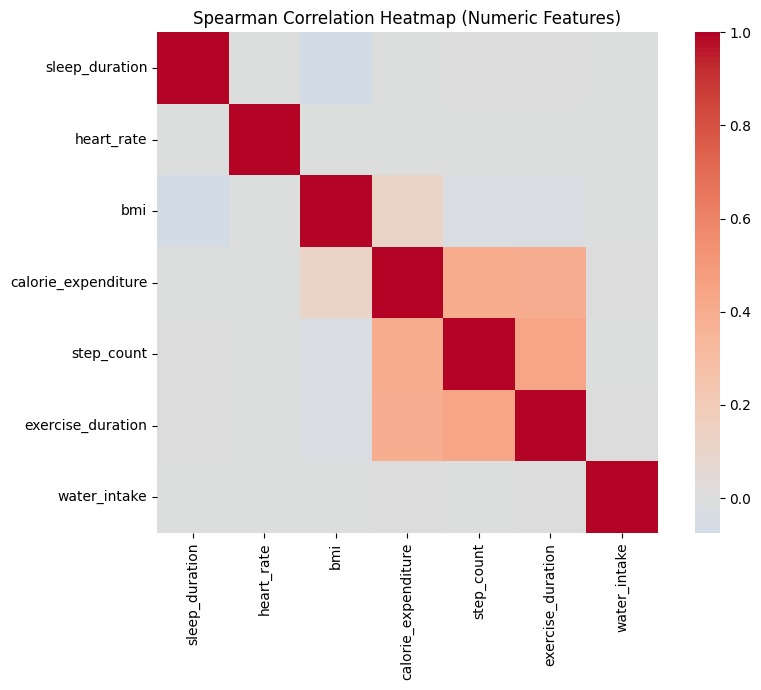

In [40]:
corr = train[num_cols].corr(method='pearson')

plt.figure(figsize=(9,7))
sns.heatmap(corr, cmap='coolwarm', center=0, square=True)
plt.title("Spearman Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.show()

In [41]:
corr

,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake
sleep_duration,1.000000,-0.005183,-0.074576,-0.004075,0.004082,0.001708,0.000519
heart_rate,-0.005183,1.000000,0.000612,-0.003967,-0.005486,-0.005679,0.000192
bmi,-0.074576,0.000612,1.000000,0.117624,-0.020548,-0.020289,0.000638
calorie_expenditure,-0.004075,-0.003967,0.117624,1.000000,0.400102,0.393592,0.001534
step_count,0.004082,-0.005486,-0.020548,0.400102,1.000000,0.438236,-0.000588
exercise_duration,0.001708,-0.005679,-0.020289,0.393592,0.438236,1.000000,0.002199
water_intake,0.000519,0.000192,0.000638,0.001534,-0.000588,0.002199,1.000000


In [42]:
print(num_cols)
print(cat_cols)

['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake']
['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']


In [43]:
numeric_preprocess = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_preprocess = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_preprocess, num_cols),
        ('cat', categorical_preprocess, cat_cols)
    ]
)

In [44]:
RANDOM_STATE = 2

In [45]:
X = train.drop(columns=[TARGET]).copy()
y = train[TARGET].copy()
if ID_COL in X.columns:
    X = X.drop(columns=[ID_COL])

In [46]:
models = {
    'logreg': LogisticRegression(
        max_iter=1200,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ),
    'random_forest': RandomForestClassifier(
        n_estimators=120,
        class_weight='balanced_subsample',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    'extra_trees': ExtraTreesClassifier(
        n_estimators=180,
        class_weight='balanced_subsample',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

In [47]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
scoring = {'bal_acc': make_scorer(balanced_accuracy_score)}

In [48]:
rows = []
for name, model in models.items():
    print(f"\nRunning {name} ...")
    pipe = Pipeline([('preprocessor', preprocessor), ('model', model)])
    res = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=1, return_train_score=False)
    mean_score = res['test_bal_acc'].mean()
    std_score = res['test_bal_acc'].std()
    rows.append({'model': name, 'cv_bal_acc_mean': mean_score, 'cv_bal_acc_std': std_score})
    print(f"{name} done | mean={mean_score:.6f} std={std_score:.6f}")

results = pd.DataFrame(rows).sort_values('cv_bal_acc_mean', ascending=False).reset_index(drop=True)
display(results)


Running logreg ...
logreg done | mean=0.899543 std=0.000583

Running random_forest ...
random_forest done | mean=0.863906 std=0.001056

Running extra_trees ...
extra_trees done | mean=0.845266 std=0.000661


,model,cv_bal_acc_mean,cv_bal_acc_std
0,logreg,0.899543,0.000583
1,random_forest,0.863906,0.001056
2,extra_trees,0.845266,0.000661


In [49]:
models_2 = {
    "histboost": HistGradientBoostingClassifier(
        random_state=RANDOM_STATE
    ),
    "lightgbm": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "xgboost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="multi:softprob",   # use "binary:logistic" if binary target
        eval_metric="mlogloss",       # use "logloss" if binary target
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
}

In [51]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_enc = le.fit_transform(y)   # at-risk/fit/unhealthy -> 0/1/2

In [52]:
new_rows = []
for name, model in models_2.items():
    print(f"\nRunning {name} ...")
    pipe = Pipeline([('preprocessor', preprocessor), ('model', model)])
    res = cross_validate(pipe, X, y_enc, cv=cv, scoring=scoring, n_jobs=1, return_train_score=False)
    mean_score = res['test_bal_acc'].mean()
    std_score = res['test_bal_acc'].std()
    new_rows.append({'model': name, 'cv_bal_acc_mean': mean_score, 'cv_bal_acc_std': std_score})
    print(f"{name} done | mean={mean_score:.6f} std={std_score:.6f}")

new_results = pd.DataFrame(new_rows)
results = pd.concat([results, new_results], ignore_index=True)
results = results.drop_duplicates(subset=['model'], keep='last')
results = results.sort_values('cv_bal_acc_mean', ascending=False).reset_index(drop=True)

display(results)


Running histboost ...
histboost done | mean=0.869567 std=0.000217

Running lightgbm ...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013939 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1833
[LightGBM] [Info] Number of data points in the train set: 460058, number of used features: 31
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014287 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1833
[LightGBM] [Info] Number of data points in the train set: 460059, number of used features: 31
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014170 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1833
[LightGBM] [Info] Number of data points in the train set: 460059, number of used features: 31
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


lightgbm done | mean=0.949419 std=0.000649

Running xgboost ...
xgboost done | mean=0.869854 std=0.000676


,model,cv_bal_acc_mean,cv_bal_acc_std
0,lightgbm,0.949419,0.000649
1,logreg,0.899543,0.000583
2,xgboost,0.869854,0.000676
3,histboost,0.869567,0.000217
4,random_forest,0.863906,0.001056
5,extra_trees,0.845266,0.000661


In [53]:
from sklearn.model_selection import RandomizedSearchCV

In [56]:
pipe_lgbm = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LGBMClassifier(
        objective="multiclass",
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1,
        force_row_wise=True
    ))
])

param_dist = {
    "model__n_estimators": [200, 300, 400, 600],
    "model__learning_rate": [0.03, 0.05, 0.08],
    "model__num_leaves": [31, 63, 127],
    "model__max_depth": [-1, 6, 10],
    "model__min_child_samples": [20, 50, 100],
    "model__subsample": [0.7, 0.85, 1.0],
    "model__colsample_bytree": [0.7, 0.85, 1.0],
    "model__reg_alpha": [0.0, 0.1, 1.0],
    "model__reg_lambda": [0.0, 0.1, 1.0],
}

search_lgbm = RandomizedSearchCV(
    pipe_lgbm,
    param_distributions=param_dist,
    n_iter=25,
    scoring=make_scorer(balanced_accuracy_score),
    cv=cv,
    n_jobs=1,
    verbose=1,
    random_state=RANDOM_STATE,
    refit=True
)

search_lgbm.fit(X, y_enc)

print("Best CV bal_acc:", search_lgbm.best_score_)
print("Best params:", search_lgbm.best_params_)


Fitting 3 folds for each of 25 candidates, totalling 75 fits


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

Best CV bal_acc: 0.9494789126043967
Best params: {'model__subsample': 0.85, 'model__reg_lambda': 1.0, 'model__reg_alpha': 1.0, 'model__num_leaves': 31, 'model__n_estimators': 400, 'model__min_child_samples': 100, 'model__max_depth': 10, 'model__learning_rate': 0.03, 'model__colsample_bytree': 0.85}


In [59]:
best_lgbm_pipe = search_lgbm.best_estimator_

In [63]:
test.shape

(295753, 14)

In [64]:
test = pd.read_csv('/kaggle/input/competitions/playground-series-s6e7/test.csv')
assert test.shape[0] == 295753, f"test has {test.shape[0]} rows, expected 295753"

pred_enc = best_lgbm_pipe.predict(test)
assert len(pred_enc) == test.shape[0]

pred_labels = le.inverse_transform(pred_enc)

submission = pd.DataFrame({
    "id": test["id"],
    "health_condition": pred_labels
})

assert submission.shape[0] == 295753
assert set(submission["health_condition"].unique()) <= set(le.classes_)

submission.to_csv("submission_lgbm_tuned.csv", index=False)
submission.head()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,id,health_condition
0,690088,unhealthy
1,690089,unhealthy
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy


In [66]:
import joblib
joblib.dump(best_lgbm_pipe, "model.pkl")
joblib.dump(le, "label_encoder.pkl")

print("Saved:", best_lgbm_pipe.__class__.__name__, "and", le.__class__.__name__)

Saved: Pipeline and LabelEncoder
